# Phase 1: dataset setup and propagation-tree exploration

This notebook prepares the raw propagation datasets for the first phase of the InfoGuard project. It loads the project-wide paths and dataset settings from `config.py`, checks that Twitter15, Twitter16, WICO Text, and WICO Graph are available, and normalizes their metadata into a common cascade catalog.

The work carried out here is:

1. Load central configuration and create the configured project directories.
2. Inspect Twitter15 and Twitter16 labels, source tweets, and propagation-tree files.
3. Load WICO Text as the source of tweet/status text and labels.
4. Load WICO Graph as the source of graph edges and cascade structure.
5. Join WICO Text and WICO Graph by normalized tweet/content identifiers while keeping unmatched graph cascades visible.
6. Parse each propagation tree into a directed graph with root, edge, depth, width, cascade-size, and branching-ratio statistics.
7. Save reusable Phase 1 artifacts under the configured evaluation directory for visualization and later modeling.

The paper motivates this workflow by treating misinformation control as a propagation-structure problem: true and false content can spread differently through social networks, so cascade structure is useful beyond text-only classification.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import json
import math
import os
import re
import random
import sys

import numpy as np
import pandas as pd
import networkx as nx

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

for candidate in [Path.cwd(), Path.cwd().parent, Path('/mnt/data')]:
    if (candidate / 'config.py').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

try:
    from config import cfg, ROOT as CONFIG_ROOT
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'Could not import config.py. Place config.py in the project root '
        'or start Jupyter from the project root.'
    ) from exc

RANDOM_SEED = cfg.seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(CONFIG_ROOT).resolve()
EVAL_DIR = cfg.paths.evaluation
EVAL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_colwidth', 160)
print(f'Project root: {PROJECT_ROOT}')
print(f'Evaluation directory: {EVAL_DIR}')


Project root: /home/krmsh1n5/Desktop/UFAZ/infoshield
Evaluation directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation


## 1. Load paths from `config.py`

All dataset and output paths come from the central configuration object. This keeps both notebooks consistent with the rest of the project and avoids hard-coded local paths.


In [2]:
# cfg.paths.make_all() would create a spurious bigcn_best.pt/ directory.
# Create only the directories we actually need.
_DIRS_TO_CREATE = [
    cfg.paths.data_raw,
    cfg.paths.wico_text,
    cfg.paths.wico_graph,
    cfg.paths.twitter15,
    cfg.paths.twitter16,
    cfg.paths.twitter15_trees,
    cfg.paths.twitter16_trees,
    cfg.paths.data_processed,
    cfg.paths.graphs_pt,
    cfg.paths.sbm_matrices,
    cfg.paths.checkpoints,
    cfg.paths.evaluation,
]
for _d in _DIRS_TO_CREATE:
    _d.mkdir(parents=True, exist_ok=True)
print('\u2713 Project directories ready.')

TWITTER15_DIR  = cfg.paths.twitter15
TWITTER16_DIR  = cfg.paths.twitter16
WICO_GRAPH_DIR = cfg.paths.wico_graph
WICO_TEXT_DIR  = cfg.paths.wico_text

CONFIGURED_PATHS = {
    'Twitter15':        TWITTER15_DIR,
    'Twitter16':        TWITTER16_DIR,
    'WICO Text':        WICO_TEXT_DIR,
    'WICO Graph':       WICO_GRAPH_DIR,
    'Processed graphs': cfg.paths.graphs_pt,
    'SBM matrices':     cfg.paths.sbm_matrices,
    'Evaluation':       EVAL_DIR,
}

path_rows = []
for name, path in CONFIGURED_PATHS.items():
    path = Path(path)
    path_rows.append({'name': name, 'path': str(path),
                      'exists': path.exists(), 'is_dir': path.is_dir()})
paths_df = pd.DataFrame(path_rows)
display(paths_df)

missing_inputs = [
    name for name, path in {
        'Twitter15': TWITTER15_DIR, 'Twitter16': TWITTER16_DIR,
        'WICO Text': WICO_TEXT_DIR, 'WICO Graph': WICO_GRAPH_DIR,
    }.items() if not Path(path).exists()
]
if missing_inputs:
    print('Missing dataset directories:', ', '.join(missing_inputs))
    print('Download the missing datasets before running the full notebook.')


✓ Project directories ready.


,name,path,exists,is_dir
0,Twitter15,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15,True,True
1,Twitter16,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter16,True,True
2,WICO Text,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text,True,True
3,WICO Graph,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph,True,True
4,Processed graphs,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/graphs,True,True
5,SBM matrices,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/processed/sbm_matrices,True,True
6,Evaluation,/home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation,True,True


## 2. General parsing helpers

The datasets use different formats. These helpers normalize labels and parse edge files defensively.

In [4]:
TRUE_LABELS = {
    'true', 'non-rumor', 'nonrumor', 'non_rumor', 'real',
    'non-conspiracy', 'non conspiracy', 'nonconspiracy', 'not conspiracy', 'credible'
}
FALSE_LABELS = {
    'false', 'rumor', 'fake',
    '5g-corona',
    '5g-corona conspiracy', '5g corona conspiracy',
    'other conspiracy', 'other-conspiracy',
    'conspiracy', 'misinformation', 'disinformation'
}


def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s[:-2]
    return s


def normalize_label(label):
    if label is None or pd.isna(label):
        return 'unknown'
    s = str(label).strip().lower().replace('_', ' ').replace('-', ' ')
    s = re.sub(r'\s+', ' ', s)
    norm_true  = {x.replace('_', ' ').replace('-', ' ') for x in TRUE_LABELS}
    norm_false = {x.replace('_', ' ').replace('-', ' ') for x in FALSE_LABELS}
    if s in norm_true:
        return 'true'
    if s in norm_false:
        return 'false'
    if 'non' in s and ('rumor' in s or 'conspiracy' in s):
        return 'true'
    if any(k in s for k in ['false', 'fake', 'rumor', 'conspiracy', 'misinfo', 'disinfo']):
        return 'false'
    if any(k in s for k in ['true', 'real', 'credible']):
        return 'true'
    return 'unknown'


def parse_edge_line(line):
    """Parse one edge line from a Twitter15/16 tree file.

    Format (config.py Twitter15Config):
        ['parent_uid', 'parent_tweet_id', 'delay_min']->['child_uid', 'child_tweet_id', 'delay_min']

    Root sentinel:
        ['ROOT', 'ROOT', '0.0']->['source_uid', 'source_tweet_id', '0.0']

    All nodes are USER IDs (field 0 of each bracket).
    Returns (parent_uid, child_uid, delay_float) or None.
    """
    raw = line.strip()
    if not raw or '->' not in raw:
        return None
    halves = raw.split('->', 1)
    if len(halves) != 2:
        return None

    def extract_fields(s):
        return re.findall(r"'([^']*?)'", s)

    parent_fields = extract_fields(halves[0])
    child_fields  = extract_fields(halves[1])
    if not parent_fields or not child_fields:
        return None
    parent_uid = normalize_id(parent_fields[0])
    child_uid  = normalize_id(child_fields[0])
    delay = None
    if len(child_fields) >= 3:
        try:
            delay = float(child_fields[2])
        except ValueError:
            pass
    return parent_uid, child_uid, delay


def graph_from_edges(edge_rows):
    """Build a DiGraph from (parent_uid, child_uid, delay) tuples.

    FIX: the ROOT sentinel line identifies the source user (its child_uid)
    as the tree root.  No phantom ROOT node is added to the graph, so all
    node IDs stay in the same user-ID namespace.

    Returns (G, root_user_id).
    """
    ROOT_SENTINEL = cfg.twitter15.root_sentinel  # 'ROOT'
    G = nx.DiGraph()
    root_user_id = None

    for parent, child, delay in edge_rows:
        parent = normalize_id(parent)
        child  = normalize_id(child)
        if parent is None or child is None:
            continue
        if parent.upper() == ROOT_SENTINEL.upper():
            # child IS the source tweeter: record as root, skip this edge
            if root_user_id is None:
                root_user_id = child
            G.add_node(child)
        else:
            G.add_edge(parent, child)
            if delay is not None:
                G.nodes[child]['delay'] = delay

    return G, root_user_id


def find_roots(G):
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    return roots or list(G.nodes)[:1]


def tree_stats(G, root_id=None):
    """Compute structural statistics for a propagation tree.

    FIX: temporal_span checks both 'delay' (Twitter15/16) and 'time'
    (WICO nodes.csv) node attributes.
    """
    root_id = normalize_id(root_id)
    if root_id not in G and G.number_of_nodes() > 0:
        root_id = find_roots(G)[0]
    depths = {}
    if root_id in G:
        try:
            depths = nx.single_source_shortest_path_length(G, root_id)
        except Exception:
            depths = {}
    depth_counts = Counter(depths.values())
    cascade_size = G.number_of_nodes()
    max_depth    = max(depth_counts.keys())    if depth_counts else 0
    max_width    = max(depth_counts.values())  if depth_counts else cascade_size
    # Accept 'delay' (Twitter propagation delay) or 'time' (WICO account age)
    delays = []
    for _, v in G.nodes(data=True):
        for attr in ('delay', 'time'):
            val = v.get(attr)
            if val is not None:
                try:
                    delays.append(float(val))
                    break
                except (TypeError, ValueError):
                    pass
    temporal_span   = max(delays) - min(delays) if len(delays) >= 2 else float('nan')
    branching_ratio = G.number_of_edges() / max(1, cascade_size)
    return {
        'num_nodes':       cascade_size,
        'num_edges':       G.number_of_edges(),
        'cascade_size':    cascade_size,
        'max_depth':       max_depth,
        'max_width':       max_width,
        'branching_ratio': branching_ratio,
        'num_roots':       len(find_roots(G)),
        'is_arborescence': nx.is_arborescence(G) if G.number_of_nodes() > 0 else False,
        'temporal_span':   temporal_span,
    }

print('Helpers defined.')


Helpers defined.


## 3. Load Twitter15 and Twitter16

These datasets typically include root tweet text, labels, and one propagation-tree file per root tweet.

In [5]:
def load_twitter_labels(dataset_dir, dataset_cfg=None):
    """Read label.txt -> DataFrame[tweet_id, raw_label, label]."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    dataset_dir = Path(dataset_dir)
    label_file  = dataset_dir / dataset_cfg.label_file
    rows = []
    if label_file.exists():
        for line in label_file.read_text(errors='ignore').splitlines():
            line = line.strip()
            if not line or ':' not in line:
                continue
            label, tweet_id = line.split(':', 1)
            rows.append({
                'tweet_id':  normalize_id(tweet_id),
                'raw_label': label.strip(),
                'label':     normalize_label(label.strip()),
            })
    return (pd.DataFrame(rows).drop_duplicates('tweet_id')
            if rows else pd.DataFrame(columns=['tweet_id', 'raw_label', 'label']))


def load_twitter_source_tweets(dataset_dir, dataset_cfg=None):
    """Read source_tweets.txt -> DataFrame[tweet_id, text]."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    dataset_dir = Path(dataset_dir)
    source_file = dataset_dir / dataset_cfg.source_tweets_file
    rows = []
    if source_file.exists():
        for line in source_file.read_text(errors='ignore').splitlines():
            line = line.strip()
            if not line or '\t' not in line:
                continue
            tweet_id, text = line.split('\t', 1)
            rows.append({'tweet_id': normalize_id(tweet_id), 'text': text})
    return (pd.DataFrame(rows).drop_duplicates('tweet_id')
            if rows else pd.DataFrame(columns=['tweet_id', 'text']))


def find_tree_files(trees_subdir, dataset_cfg=None):
    """Return all .txt tree files, skipping label/source files."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    trees_path  = Path(trees_subdir)
    if not trees_path.exists():
        return []
    skip = {dataset_cfg.label_file, dataset_cfg.source_tweets_file}
    return sorted(p for p in trees_path.glob('*.txt') if p.name not in skip)


def load_twitter_tree(path, tweet_id=None):
    """Parse one tree .txt file into (DiGraph, root_user_id).

    FIX: uses graph_from_edges() which resolves the ROOT sentinel to the
    actual source user ID (not the file stem / tweet ID).
    """
    rows = []
    for line in Path(path).read_text(errors='ignore').splitlines():
        parsed = parse_edge_line(line)
        if parsed:
            rows.append(parsed)
    G, root_user_id = graph_from_edges(rows)
    G.graph['tweet_id'] = normalize_id(tweet_id or Path(path).stem)
    return G, root_user_id


def load_twitter_dataset(name, dataset_dir, trees_subdir, dataset_cfg=None):
    """Load labels, source tweets, and all tree graphs for one Twitter dataset."""
    dataset_cfg = dataset_cfg or cfg.twitter15
    if dataset_dir is None or not Path(dataset_dir).exists():
        print(f'{name}: dataset directory not found.')
        return pd.DataFrame(), {}
    labels     = load_twitter_labels(dataset_dir, dataset_cfg)
    texts      = load_twitter_source_tweets(dataset_dir, dataset_cfg)
    meta       = labels.merge(texts, on='tweet_id', how='outer')
    meta['dataset'] = name
    tree_files = find_tree_files(trees_subdir, dataset_cfg)
    graphs = {}
    for path in tree_files:
        tweet_id = normalize_id(path.stem)
        G, root_user_id = load_twitter_tree(path, tweet_id=tweet_id)
        n = G.number_of_nodes()
        if dataset_cfg.min_tree_size <= n <= dataset_cfg.max_tree_size:
            graphs[tweet_id] = {
                'graph':    G,
                'path':     str(path),
                'root_id':  root_user_id,  # user ID of source tweeter
                'tweet_id': tweet_id,
            }
    print(f'{name}: {len(meta)} label/text rows, {len(graphs)} trees '
          f'(size filter {dataset_cfg.min_tree_size}\u2013{dataset_cfg.max_tree_size})')
    return meta, graphs


twitter15_meta, twitter15_graphs = load_twitter_dataset(
    'Twitter15', TWITTER15_DIR, cfg.paths.twitter15_trees, cfg.twitter15
)
twitter16_meta, twitter16_graphs = load_twitter_dataset(
    'Twitter16', TWITTER16_DIR, cfg.paths.twitter16_trees, cfg.twitter16
)

display(pd.concat([twitter15_meta.head(5), twitter16_meta.head(5)], ignore_index=True))


Twitter15: 1490 label/text rows, 1463 trees (size filter 3–2000)
Twitter16: 818 label/text rows, 800 trees (size filter 3–2000)


,tweet_id,raw_label,label,text,dataset
0,265953285247209472,false,false,deep-fried left wings demo-crab cakes barack-amole & chips malia quesadillas hawaiian pizza sloppy joe bidens obamacare-rot cake,Twitter15
1,273182568298450945,false,false,42 million dead in bloodiest black friday weekend on record URL,Twitter15
2,273278761909239808,false,false,42 million dead in bloodiest black friday weekend on record URL,Twitter15
3,295152287901417472,true,true,#prayforchristopher 5k run .. well we are walking lol @savannahn_2012 @lemongella URL,Twitter15
4,295944137948151809,false,false,a photo of black nurses saving the life of a kkk member. URL,Twitter15
5,498430783699554305,true,true,witness: police allegedly stopped mike brown after yelling at him to walk on sidewalk. #ferguson URL,Twitter16
6,500378223977721856,true,true,"oh. so now the #ferguson police chief says the cop didn't know about the robbery when he stopped #mikebrown. the kid was ""jaywalking""? bs!",Twitter16
7,524922729485848576,true,true,only photo i will tweet. cpr being performed on the soldier now. i heard four shots. #ottawa URL,Twitter16
8,524923462398513152,true,true,shots fired on parliament hill after a man walked up with a gun. i'm locked in a security office on parliament hill,Twitter16
9,524923676484177920,true,true,breaking - shooting on parliament hill. rcmp have weapons drawn #cdnpoli URL,Twitter16


## 3b. Single-tree anatomy

Before computing bulk statistics, walk through one specific tree in detail.
This confirms the parser is correct and makes the graph structure concrete.
Each measure computed here maps directly to a quantity used in the paper:
- `cascade_size` → R∞ (final infected set size the LP tries to minimise)
- `max_depth` → how many SIR iterations the cascade ran
- `branching_ratio` → the α parameter the LP preserves for true content


In [6]:
# Pick the largest false-content tree from Twitter15 for the anatomy walk
anatomy_id = None
if twitter15_graphs:
    labels_lookup = (twitter15_meta.set_index('tweet_id')['label'].to_dict()
                     if not twitter15_meta.empty else {})
    false_ids = [
        tid for tid in twitter15_graphs
        if normalize_label(labels_lookup.get(tid, 'unknown')) == 'false'
    ]
    if false_ids:
        anatomy_id = max(false_ids,
                         key=lambda t: twitter15_graphs[t]['graph'].number_of_nodes())

if anatomy_id is None:
    print('No false-content tree found. Using first available tree.')
    anatomy_id = next(iter(twitter15_graphs), None)

if anatomy_id:
    payload   = twitter15_graphs[anatomy_id]
    G         = payload['graph']
    root_id   = payload.get('root_id')  # user ID of source tweeter
    row       = (twitter15_meta[twitter15_meta['tweet_id'].eq(anatomy_id)]
                 if not twitter15_meta.empty else pd.DataFrame())
    root_text = (row['text'].values[0]
                 if not row.empty and 'text' in row.columns else '[text not found]')

    bfs_root   = (root_id if (root_id and root_id in G)
                  else (find_roots(G)[0] if G.number_of_nodes() > 0 else None))
    depths     = nx.single_source_shortest_path_length(G, bfs_root) if bfs_root else {}
    depth_dist = Counter(depths.values())
    leaves     = [n for n in G.nodes if G.out_degree(n) == 0]
    non_leaf_d = [d for _, d in G.out_degree() if d > 0]

    print('=== SINGLE-TREE ANATOMY ===')
    print(f'Tweet ID (file stem)  : {anatomy_id}')
    print(f'Root user ID          : {root_id}')
    print(f'Root text             : "{root_text[:120]}"')
    print()
    print(f'Nodes (users who participated) : {G.number_of_nodes()}')
    print(f'Edges (content transfers)      : {G.number_of_edges()}')
    print(f'Is valid tree (arborescence)   : {nx.is_arborescence(G)}')
    print()
    print(f'Root node (original poster)    : {bfs_root}')
    print(f'Leaf nodes (no further spread) : {len(leaves)}')
    print(f'Max cascade depth              : {max(depth_dist) if depth_dist else 0}')
    print(f'Nodes per depth level          : {dict(sorted(depth_dist.items()))}')
    avg_b = f'{np.mean(non_leaf_d):.3f}' if non_leaf_d else 'N/A'
    print(f'Avg branching factor           : {avg_b}')
    print()
    print('--- What each measure means for the paper ---')
    print('Nodes            = |It| across all SIR iterations = R\u221e (final cascade size)')
    print('Edges            = individual p_ij content transfers (eq. 4 of the paper)')
    print('Max depth        = number of SIR cascade steps before propagation stopped')
    print('Branching factor = empirical branching ratio \u2248 \u03b1 the LP must preserve')
    print('                   Paper tests \u03b1 \u2208 {1.5, 2.0, 3.0} \u2014 our data gives the range')
else:
    print('No trees loaded \u2014 check that Twitter15 data path is correct.')


=== SINGLE-TREE ANATOMY ===
Tweet ID (file stem)  : 295944137948151809
Root user ID          : 1109500842
Root text             : "a photo of black nurses saving the life of a kkk member. URL"

Nodes (users who participated) : 1991
Edges (content transfers)      : 2000
Is valid tree (arborescence)   : False

Root node (original poster)    : 1109500842
Leaf nodes (no further spread) : 1652
Max cascade depth              : 5
Nodes per depth level          : {0: 1, 1: 1514, 2: 353, 3: 93, 4: 24, 5: 6}
Avg branching factor           : 5.900

--- What each measure means for the paper ---
Nodes            = |It| across all SIR iterations = R∞ (final cascade size)
Edges            = individual p_ij content transfers (eq. 4 of the paper)
Max depth        = number of SIR cascade steps before propagation stopped
Branching factor = empirical branching ratio ≈ α the LP must preserve
                   Paper tests α ∈ {1.5, 2.0, 3.0} — our data gives the range


## 4. Load WICO Text separately

WICO Text is used for labels and textual metadata. It may not contain propagation edges.

In [7]:
def load_wico_text_dataset(wico_text_dir):
    """Load WICO Text: one .txt file per class, each line is a bare tweet ID."""
    if wico_text_dir is None or not Path(wico_text_dir).exists():
        print('WICO Text directory not found.')
        return pd.DataFrame(columns=['content_id','tweet_id','raw_label','label','text_path'])
    wico_text_dir = Path(wico_text_dir)
    int_to_name = {v: k for k, v in cfg.wico.label_map.items()}
    rows = []
    for label_int, fname in cfg.wico.text_files.items():
        path = wico_text_dir / fname
        if not path.exists():
            print(f'  Missing WICO Text file: {path}')
            continue
        raw_label  = int_to_name.get(label_int, str(label_int))
        norm_label = normalize_label(raw_label)
        for line in path.read_text(errors='ignore').splitlines():
            tweet_id = normalize_id(line.strip())
            if tweet_id is None:
                continue
            rows.append({
                'content_id': tweet_id,
                'tweet_id':   tweet_id,
                'raw_label':  raw_label,
                'label':      norm_label,
                'text_path':  str(path),
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.drop_duplicates('content_id')
    print(f'WICO Text: {len(out)} tweet IDs across {len(cfg.wico.text_files)} files')
    return out

wico_text = load_wico_text_dataset(WICO_TEXT_DIR)
display(wico_text.head())
display(wico_text['label'].value_counts(dropna=False).rename('count').to_frame()
        if not wico_text.empty else wico_text)


WICO Text: 9688 tweet IDs across 3 files


,content_id,tweet_id,raw_label,label,text_path
0,1037704685652561926,1037704685652561926,5g-corona,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
1,1200224860561199104,1200224860561199104,5g-corona,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
2,1221197064740143104,1221197064740143104,5g-corona,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
3,1221428849881370626,1221428849881370626,5g-corona,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt
4,1222024051830509568,1222024051830509568,5g-corona,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-text/5g_corona_conspiracy.txt


,count
label,
true,6618
false,3070


## 5. Load WICO Graph separately

WICO Graph provides propagation structure. The parser below groups graph files by content ID when files are one cascade each. If the graph files contain columns, it tries to infer source, target, and cascade/content ID columns.

In [8]:
def _wico_find_root(G, nodes_df):
    """Choose the best root node for a WICO propagation graph.

    WICO edges.txt is a follower/connection graph around a tweet.  The
    folder name is the tweet ID (different namespace from user IDs in
    edges.txt/nodes.csv) so we must NOT add it as a graph node.

    Priority:
      1. Node with the highest 'followers' count in nodes.csv.
      2. Node with the highest in-degree in the graph.
      3. First node in nodes.csv that appears in the graph.
    """
    if not nodes_df.empty and 'id' in nodes_df.columns:
        if 'followers' in nodes_df.columns:
            cands = nodes_df[nodes_df['id'].map(normalize_id).isin(G.nodes)].copy()
            if not cands.empty:
                try:
                    cands['followers'] = pd.to_numeric(cands['followers'], errors='coerce')
                    best = cands.loc[cands['followers'].idxmax(), 'id']
                    bid  = normalize_id(best)
                    if bid in G:
                        return bid
                except Exception:
                    pass
        for _, nr in nodes_df.iterrows():
            nid = normalize_id(nr.get('id'))
            if nid and nid in G:
                return nid
    if G.number_of_nodes() > 0:
        return max(G.nodes, key=lambda n: G.in_degree(n))
    return None


def load_wico_graph_cascade(tweet_dir):
    """Load one cascade from a per-tweet WICO Graph directory.

    FIX: the folder name (tweet ID) is NOT added as a graph node because
    it lives in a different namespace from the user IDs in edges.txt and
    nodes.csv.  _wico_find_root() selects the most-followed user as root.

    Returns (G, root_user_id).
    """
    tweet_dir  = Path(tweet_dir)
    edges_path = tweet_dir / cfg.wico.graph_edges_file
    G = nx.DiGraph()
    if edges_path.exists():
        for line in edges_path.read_text(errors='ignore').splitlines():
            parts = line.strip().split()
            if len(parts) == 2:
                src, dst = normalize_id(parts[0]), normalize_id(parts[1])
                if src and dst:
                    G.add_edge(src, dst)

    nodes_path = tweet_dir / cfg.wico.graph_nodes_file
    nodes_df   = pd.DataFrame()
    if nodes_path.exists():
        nodes_df = pd.read_csv(nodes_path, dtype=str)
        nodes_df.columns = [c.strip().lower() for c in nodes_df.columns]
        for col in list(cfg.wico.graph_nodes_columns):
            if col not in nodes_df.columns:
                nodes_df[col] = None
        for _, row in nodes_df.iterrows():
            nid = normalize_id(row['id'])
            if nid:
                G.add_node(nid)
                for feat in ('time', 'friends', 'followers'):
                    try:
                        G.nodes[nid][feat] = int(float(row[feat]))
                    except (ValueError, KeyError, TypeError):
                        pass

    root_user_id        = _wico_find_root(G, nodes_df)
    G.graph['tweet_id'] = normalize_id(tweet_dir.name)
    return G, root_user_id


def load_wico_graph_dataset(wico_graph_dir):
    """Walk cfg.wico.graph_dirs and load every per-tweet cascade."""
    if wico_graph_dir is None or not Path(wico_graph_dir).exists():
        print('WICO Graph directory not found.')
        return {}, pd.DataFrame(columns=['content_id', 'graph_path', 'label_int'])
    wico_graph_dir = Path(wico_graph_dir)
    graphs = {}
    manifest_rows = []
    for label_int, folder_name in cfg.wico.graph_dirs.items():
        class_dir = wico_graph_dir / folder_name
        if not class_dir.exists():
            print(f'  Missing WICO Graph folder: {class_dir}')
            continue
        tweet_dirs = sorted(p for p in class_dir.iterdir() if p.is_dir())
        for tweet_dir in tweet_dirs:
            G, root_user_id = load_wico_graph_cascade(tweet_dir)
            if G.number_of_nodes() == 0:
                continue
            content_id = normalize_id(tweet_dir.name)
            graphs[content_id] = {
                'graph':    G,
                'path':     str(tweet_dir),
                'root_id':  root_user_id,  # user ID, NOT folder name
                'tweet_id': content_id,
            }
            manifest_rows.append({
                'content_id': content_id,
                'graph_path': str(tweet_dir),
                'label_int':  label_int,
            })
    print(f'WICO Graph: {len(graphs)} cascades from {len(cfg.wico.graph_dirs)} class folders')
    manifest = (pd.DataFrame(manifest_rows).drop_duplicates('content_id')
                if manifest_rows else pd.DataFrame(
                    columns=['content_id', 'graph_path', 'label_int']))
    return graphs, manifest

wico_graphs, wico_graph_manifest = load_wico_graph_dataset(WICO_GRAPH_DIR)
display(wico_graph_manifest.head())


WICO Graph: 2502 cascades from 3 class folders


,content_id,graph_path,label_int
0,1,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/1,0
1,10,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/10,0
2,100,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/100,0
3,101,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/101,0
4,102,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/102,0


## 6. Join WICO Text and WICO Graph

This is the important rewrite for the two-dataset case. WICO Text and WICO Graph are separate inputs, so the notebook creates a joined metadata table. Cascades without matching text labels are kept with `unknown` labels instead of being discarded.

In [9]:
def build_wico_joined_metadata(wico_text, wico_graph_manifest):
    """Assign labels from the graph subfolder structure (not tweet-ID join).

    WICO Graph folder names are sequential integers (1, 2, 3 ...).
    WICO Text stores real tweet IDs.  The two never match, so we label
    directly from label_int set by load_wico_graph_dataset.
    """
    WICO_INT_TO_LABEL = {0: 'false', 1: 'false', 2: 'true'}
    WICO_INT_TO_RAW   = {0: '5g-corona', 1: 'other-conspiracy', 2: 'non-conspiracy'}

    if wico_graph_manifest.empty:
        return pd.DataFrame(columns=[
            'dataset', 'tweet_id', 'content_id', 'label',
            'raw_label', 'graph_path', 'has_graph', 'has_text'
        ])

    joined = wico_graph_manifest.copy()
    joined['content_id'] = joined['content_id'].map(normalize_id)
    joined['tweet_id']   = joined['content_id']
    joined['label']      = joined['label_int'].map(WICO_INT_TO_LABEL).fillna('unknown')
    joined['raw_label']  = joined['label_int'].map(WICO_INT_TO_RAW)
    joined['dataset']    = 'WICO'
    joined['has_graph']  = True
    joined['has_text']   = False

    return joined[[
        'dataset', 'tweet_id', 'content_id', 'label',
        'raw_label', 'graph_path', 'has_graph', 'has_text'
    ]]

wico_meta = build_wico_joined_metadata(wico_text, wico_graph_manifest)
print('Joined WICO rows:', len(wico_meta))
display(wico_meta['label'].value_counts(dropna=False).rename('count').to_frame())
display(wico_meta.head())


Joined WICO rows: 2502


,count
label,
true,1905
false,597


,dataset,tweet_id,content_id,label,raw_label,graph_path,has_graph,has_text
0,WICO,1,1,false,5g-corona,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/1,True,False
1,WICO,10,10,false,5g-corona,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/10,True,False
2,WICO,100,100,false,5g-corona,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/100,True,False
3,WICO,101,101,false,5g-corona,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/101,True,False
4,WICO,102,102,false,5g-corona,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/wico-graph/5G_Conspiracy_Graphs/102,True,False


## 7. Build a unified propagation-tree catalog

The catalog records every cascade that has a graph. It also keeps labels from the appropriate metadata source.

In [10]:
all_graphs     = {}
all_meta_parts = []

for dataset_name, meta, graphs in [
    ('Twitter15', twitter15_meta, twitter15_graphs),
    ('Twitter16', twitter16_meta, twitter16_graphs),
]:
    if graphs:
        for tweet_id, payload in graphs.items():
            all_graphs[(dataset_name, tweet_id)] = payload
        if not meta.empty:
            tmp = meta.copy()
            tmp['content_id'] = tmp['tweet_id']
            tmp['has_graph']  = tmp['tweet_id'].isin(graphs.keys())
            tmp['has_text']   = (tmp['text'].fillna('').astype(str).str.len() > 0
                                 if 'text' in tmp.columns else False)
            if 'raw_label' not in tmp.columns:
                tmp['raw_label'] = None
            if 'label' not in tmp.columns:
                tmp['label'] = 'unknown'
            tmp['graph_path'] = tmp['tweet_id'].map(
                lambda x: graphs.get(normalize_id(x), {}).get('path'))
            text_col = tmp['text'] if 'text' in tmp.columns else pd.Series('', index=tmp.index)
            tmp['text'] = text_col.fillna('')
            all_meta_parts.append(
                tmp[['dataset','tweet_id','content_id','label','raw_label',
                     'text','graph_path','has_graph','has_text']])

if wico_graphs:
    for cid, payload in wico_graphs.items():
        all_graphs[('WICO', cid)] = payload
if not wico_meta.empty:
    wico_meta_aligned = wico_meta.copy()
    wico_meta_aligned['text'] = ''
    all_meta_parts.append(
        wico_meta_aligned[['dataset','tweet_id','content_id','label','raw_label',
                            'text','graph_path','has_graph','has_text']])

all_meta = (pd.concat(all_meta_parts, ignore_index=True) if all_meta_parts
            else pd.DataFrame(columns=[
                'dataset','tweet_id','content_id','label','raw_label',
                'text','graph_path','has_graph','has_text']))
all_meta['tweet_id']   = all_meta['tweet_id'].map(normalize_id)
all_meta['content_id'] = all_meta['content_id'].map(normalize_id)
all_meta['label']      = all_meta['label'].fillna('unknown').map(normalize_label)

print('Total graphs:', len(all_graphs))
print('Total metadata rows:', len(all_meta))
display(all_meta.groupby(['dataset','label']).size().rename('count').reset_index())


Total graphs: 4765
Total metadata rows: 4810


,dataset,label,count
0,Twitter15,false,370
1,Twitter15,true,746
2,Twitter15,unknown,374
3,Twitter16,false,205
4,Twitter16,true,412
5,Twitter16,unknown,201
6,WICO,false,597
7,WICO,true,1905


## 8. Compute propagation-tree statistics

These features are the Phase 1 bridge from raw files to paper-inspired modeling:

- `cascade_size` approximates final reach.
- `max_depth` captures how many reshare generations exist.
- `max_width` captures burstiness at a depth.
- `branching_ratio` approximates average edge expansion.
- `is_arborescence` checks whether the cascade is a clean tree.

In [11]:
summary_rows = []
meta_lookup  = (all_meta.set_index(['dataset','content_id']).to_dict('index')
                if not all_meta.empty else {})
for (dataset, cid), payload in all_graphs.items():
    G       = payload['graph']
    root_id = payload.get('root_id')   # user ID of source tweeter (fixed)
    stats   = tree_stats(G, root_id=root_id)
    meta    = meta_lookup.get((dataset, cid), {})
    summary_rows.append({
        'dataset':    dataset,
        'tweet_id':   cid,
        'content_id': cid,
        'root_user':  root_id,
        'label':      normalize_label(meta.get('label', 'unknown')),
        'raw_label':  meta.get('raw_label'),
        'graph_path': payload.get('path'),
        'text':       meta.get('text', ''),
        **stats,
    })

tree_summary = pd.DataFrame(summary_rows)
if not tree_summary.empty:
    tree_summary = tree_summary.sort_values(
        ['dataset','label','cascade_size'], ascending=[True, True, False])

summary_path = EVAL_DIR / 'propagation_tree_summary.csv'
tree_summary.to_csv(summary_path, index=False)
print('Saved:', summary_path)
display(tree_summary.head(20))

display(tree_summary.groupby(['dataset','label'])[
    ['cascade_size','max_depth','max_width','branching_ratio']
].describe().round(2) if not tree_summary.empty else tree_summary)


Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/propagation_tree_summary.csv


,dataset,tweet_id,content_id,root_user,label,raw_label,graph_path,text,num_nodes,num_edges,cascade_size,max_depth,max_width,branching_ratio,num_roots,is_arborescence,temporal_span
4,Twitter15,295944137948151809,295944137948151809,1109500842,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/295944137948151809.txt,a photo of black nurses saving the life of a kkk member. URL,1991,2000,1991,5,1514,1.004520,1,False,1440122.62
735,Twitter15,537377960471166976,537377960471166976,29417304,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/537377960471166976.txt,"y'all, i just read that abc paid darren wilson $500k for the interview. destroying black life remains a lucrative american career. #ferguson",1863,1907,1863,5,1227,1.023618,1,False,24541.17
900,Twitter15,560442390805090307,560442390805090307,14319981,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/560442390805090307.txt,drift into a peaceful slumber w/@thejeffbridges' new #sleepingtapes album. listen now at URL #om URL,1748,1781,1748,3,1583,1.018879,1,False,288113.27
169,Twitter15,489794593580650497,489794593580650497,271413771,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/489794593580650497.txt,breaking: malaysia airlines passenger 'shot down' near russian border in ukraine URL URL,1686,1692,1686,10,756,1.003559,1,False,6978.11
280,Twitter15,504433135036407808,504433135036407808,328810158,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/504433135036407808.txt,gonna be unreal when las vegas goes undefeated at home every year........ #nhl #expansion,1609,1619,1609,3,1498,1.006215,1,False,1031961.87
683,Twitter15,532281981795848192,532281981795848192,138749160,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/532281981795848192.txt,manager bans teen slang from work including 'chill'. adds stop accusing people of having ebola URL URL,1596,1609,1596,8,798,1.008145,1,False,400340.75
37,Twitter15,376982539132366848,376982539132366848,149760844,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/376982539132366848.txt,j.k. rowling is working on an 8th harry potter book.,1527,1546,1527,3,1437,1.012443,1,False,263645.52
454,Twitter15,521727831307722753,521727831307722753,221452291,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/521727831307722753.txt,someone spray painted a penis on a $2.4 mill bugatti URL,1435,1443,1435,4,1119,1.005575,1,False,535534.79
168,Twitter15,489794369487380480,489794369487380480,227423066,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/489794369487380480.txt,breaking: malaysian airlines passenger 'shot down' near russian border in ukraine URL URL,1388,1389,1388,6,1145,1.000720,1,False,4299.15
657,Twitter15,531607884220485632,531607884220485632,14926475,false,false,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/531607884220485632.txt,apec photo of the day. rt @marc_leibowitz: photo of vladimir putin's motorcade. posted without comment. URL,1374,1407,1374,9,442,1.024017,1,False,630015.13


cascade_size                                               \
                         count    mean     std   min     25%    50%     75%   
dataset   label                                                               
Twitter15 false          365.0  324.92  321.29  97.0  143.00  204.0  355.00   
          true           728.0  435.26  329.45  88.0  194.25  351.0  553.00   
          unknown        370.0  261.23  256.59  56.0  127.00  165.5  275.00   
Twitter16 false          198.0  293.63  266.05  74.0  136.00  211.0  331.75   
          true           405.0  468.37  355.74  90.0  213.00  337.0  659.00   
          unknown        197.0  280.39  303.12  94.0  130.00  166.0  292.00   
WICO      false          597.0   63.21   34.10   3.0   27.00   84.0   92.00   
          true          1905.0   62.68   34.91   3.0   24.00   85.0   92.00   

                          max_depth        ... max_width          \
                      max     count  mean  ...       75%     max   
dataset   label                            ...                     
Twitter15 false    1991.0     365.0  3.58  ...    271.00  1583.0   
          true     1987.0     728.0  3.59  ...    447.25  1771.0   
          unknown  1971.0     370.0  3.64  ...    216.00  1268.0   
Twitter16 false    1596.0     198.0  3.74  ...    267.00  1199.0   
          true     1949.0     405.0  3.85  ...    501.00  1465.0   
          unknown  1971.0     197.0  3.42  ...    225.00  1268.0   
WICO      false     100.0     597.0  1.66  ...      9.00    75.0   
          true      101.0    1905.0  1.57  ...      7.00    93.0   

                  branching_ratio                                             
                            count  mean   std   min   25%   50%   75%    max  
dataset   label                                                               
Twitter15 false             365.0  1.01  0.03  0.99  1.00  1.01  1.02   1.43  
          true              728.0  1.01  0.02  0.99  1.00  1.00  1.01   1.17  
          unknown           370.0  1.01  0.02  0.98  1.00  1.01  1.02   1.14  
Twitter16 false             198.0  1.01  0.03  0.99  1.00  1.00  1.02   1.17  
          true              405.0  1.01  0.02  0.99  1.00  1.00  1.01   1.11  
          unknown           197.0  1.02  0.02  0.99  1.00  1.01  1.03   1.11  
WICO      false             597.0  2.00  2.86  0.00  0.80  1.21  2.27  43.73  
          true             1905.0  1.99  2.78  0.00  0.83  1.27  2.22  50.01  

[8 rows x 32 columns]

## 8b. Branching ratio and the paper's α parameter

The LP optimizer (Algorithm 2) preserves true content by requiring its
branching ratio to stay above α after dropouts are applied. This cell
checks what fraction of our true-content trees already exceed α = 1.5
without any alteration, and shows how the distributions differ between
true and false content — the empirical foundation the dropout method relies on.


=== BRANCHING RATIO vs PAPER α PARAMETER ===
Fraction of trees with branching_ratio ≥ α (unaltered network):

  Twitter15
    α=1.0  true content:  70.5%  |  false content:  76.7%
    α=1.5  true content:   0.0%  |  false content:   0.0%
    α=2.0  true content:   0.0%  |  false content:   0.0%
    α=3.0  true content:   0.0%  |  false content:   0.0%

  Twitter16
    α=1.0  true content:  73.1%  |  false content:  66.7%
    α=1.5  true content:   0.0%  |  false content:   0.0%
    α=2.0  true content:   0.0%  |  false content:   0.0%
    α=3.0  true content:   0.0%  |  false content:   0.0%

  WICO
    α=1.0  true content:  65.0%  |  false content:  62.5%
    α=1.5  true content:  42.2%  |  false content:  40.7%
    α=2.0  true content:  30.7%  |  false content:  29.3%
    α=3.0  true content:  15.4%  |  false content:  17.9%

Interpretation:
  The LP uses α=1.5 as the default safety parameter (cfg.lp.alpha).
  It only makes sense if a significant fraction of true trees exceed
  this 

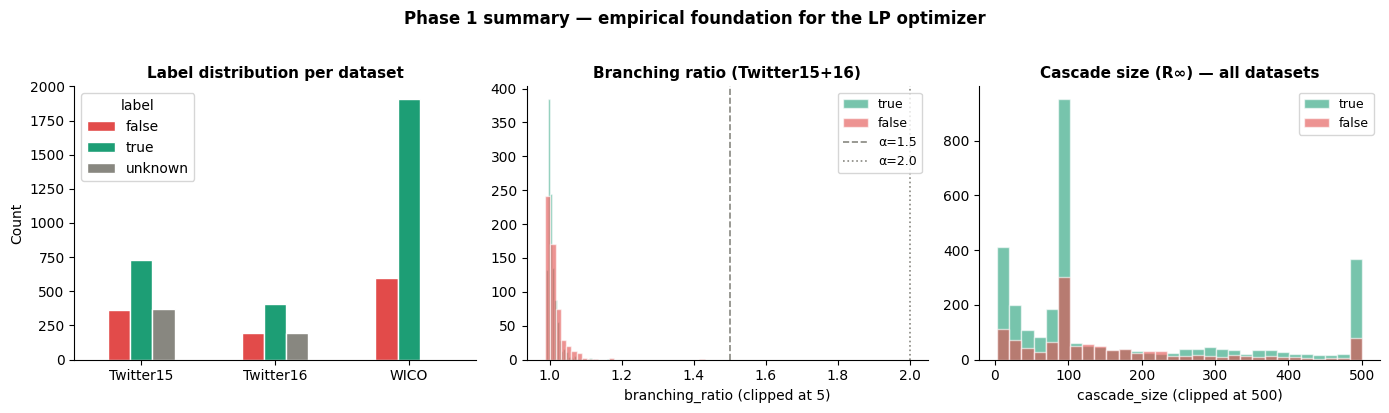

In [12]:
if not tree_summary.empty:
    ALPHA_VALUES = [1.0, 1.5, 2.0, 3.0]

    print('=== BRANCHING RATIO vs PAPER α PARAMETER ===')
    print('Fraction of trees with branching_ratio ≥ α (unaltered network):')
    print()

    for ds, grp in tree_summary.groupby('dataset'):
        true_g  = grp[grp['label'].eq('true')]['branching_ratio'].dropna()
        false_g = grp[grp['label'].eq('false')]['branching_ratio'].dropna()
        if true_g.empty and false_g.empty:
            continue
        print(f'  {ds}')
        for alpha in ALPHA_VALUES:
            t_pct = 100 * (true_g  >= alpha).mean() if len(true_g)  > 0 else float('nan')
            f_pct = 100 * (false_g >= alpha).mean() if len(false_g) > 0 else float('nan')
            print(f'    α={alpha:.1f}  true content: {t_pct:5.1f}%  |  false content: {f_pct:5.1f}%')
        print()

    print('Interpretation:')
    print('  The LP uses α=1.5 as the default safety parameter (cfg.lp.alpha).')
    print('  It only makes sense if a significant fraction of true trees exceed')
    print('  this threshold naturally — otherwise the constraint is infeasible.')
    print('  The paper reports feasibility for most events when α=1.5 or α=2.0.')
    print()

    # ── Label distribution bar chart ─────────────────────────────────────
    if plt is not None:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))

        # Plot 1: label distribution per dataset
        ax = axes[0]
        dist = tree_summary.groupby(['dataset','label']).size().unstack(fill_value=0)
        dist.plot(kind='bar', ax=ax, color=['#E24B4A','#1D9E75','#888780'], edgecolor='white')
        ax.set_title('Label distribution per dataset', fontsize=11, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)
        ax.spines[['top','right']].set_visible(False)

        # Plot 2: branching ratio distribution true vs false
        ax = axes[1]
        t15 = tree_summary[tree_summary['dataset'].isin(['Twitter15','Twitter16'])]
        for label, color in [('true','#1D9E75'), ('false','#E24B4A')]:
            vals = t15[t15['label'].eq(label)]['branching_ratio'].dropna()
            ax.hist(vals.clip(upper=5), bins=30, alpha=0.6, color=color,
                    label=label, edgecolor='white')
        for alpha_val, ls in [(1.5,'--'),(2.0,':')]:
            ax.axvline(alpha_val, color='#888780', linestyle=ls, linewidth=1.2,
                       label=f'α={alpha_val}')
        ax.set_title('Branching ratio (Twitter15+16)', fontsize=11, fontweight='bold')
        ax.set_xlabel('branching_ratio (clipped at 5)')
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)

        # Plot 3: cascade size by label
        ax = axes[2]
        for label, color in [('true','#1D9E75'), ('false','#E24B4A')]:
            vals = tree_summary[tree_summary['label'].eq(label)]['cascade_size'].dropna()
            ax.hist(vals.clip(upper=500), bins=30, alpha=0.6, color=color,
                    label=label, edgecolor='white')
        ax.set_title('Cascade size (R∞) — all datasets', fontsize=11, fontweight='bold')
        ax.set_xlabel('cascade_size (clipped at 500)')
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)

        plt.suptitle(
            'Phase 1 summary — empirical foundation for the LP optimizer',
            fontsize=12, fontweight='bold', y=1.02
        )
        plt.tight_layout()
        out = EVAL_DIR / 'phase1_summary_charts.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print('Saved:', out)
        plt.show()
else:
    print('tree_summary is empty — run cells above first.')


## 9. Select 3 to 5 example trees for visualization

The visualization notebook will use these examples. Selection prefers labeled true and false cascades with non-trivial structure.

In [13]:
def select_examples(df, per_label=3, max_total=10):
    if df.empty:
        return df
    candidates = df[df['num_edges'] > 0].copy()
    if candidates.empty:
        candidates = df.copy()
    selected = []
    for label in ['true', 'false']:
        part = candidates[candidates['label'].eq(label)].sort_values(['cascade_size','max_depth'], ascending=False)
        selected.append(part.head(per_label))
    out = pd.concat(selected, ignore_index=True) if selected else pd.DataFrame()
    if len(out) == 0:
        out = candidates.sort_values(['cascade_size','max_depth'], ascending=False).head(max_total)
    return out.head(max_total)

sample_trees = select_examples(tree_summary, per_label=3, max_total=10)
samples_path = EVAL_DIR / 'sample_tree_ids.csv'
sample_trees.to_csv(samples_path, index=False)
print('Saved:', samples_path)
display(sample_trees[['dataset','tweet_id','label','cascade_size','max_depth','max_width','graph_path']])

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/sample_tree_ids.csv


,dataset,tweet_id,label,cascade_size,max_depth,max_width,graph_path
0,Twitter15,693925198630821889,true,1987,3,1771,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/693925198630821889.txt
1,Twitter15,764505291853627392,true,1954,4,1552,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/764505291853627392.txt
2,Twitter16,674263945172119552,true,1949,7,1233,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter16/tree/674263945172119552.txt
3,Twitter15,295944137948151809,false,1991,5,1514,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/295944137948151809.txt
4,Twitter15,537377960471166976,false,1863,5,1227,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/537377960471166976.txt
5,Twitter15,560442390805090307,false,1748,3,1583,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/raw/twitter15/tree/560442390805090307.txt


## 10. Optional: quick sanity plot

This is not the final visualization. It is a quick check that the summary file looks reasonable.

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/quick_cascade_size_boxplot.png


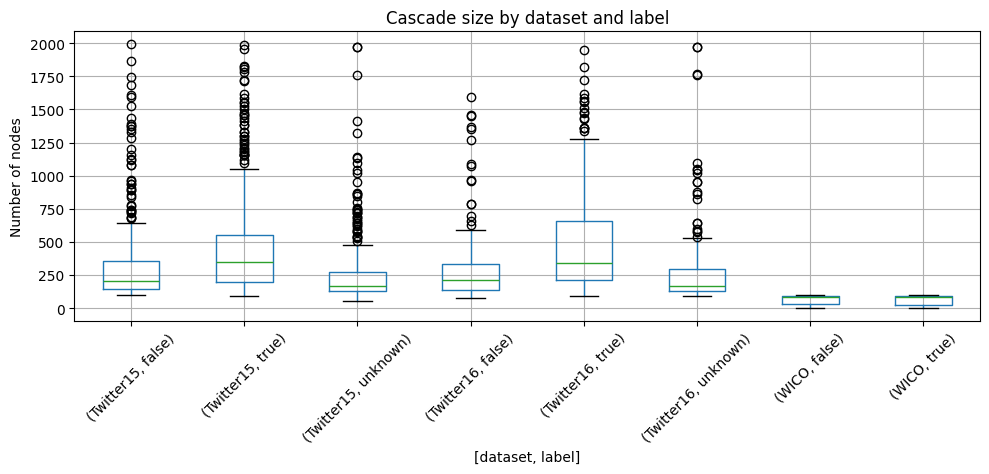

In [14]:
if plt is not None and not tree_summary.empty:
    ax = tree_summary.boxplot(column='cascade_size', by=['dataset','label'], rot=45, figsize=(10, 5))
    ax.set_title('Cascade size by dataset and label')
    ax.set_ylabel('Number of nodes')
    plt.suptitle('')
    plt.tight_layout()
    out = EVAL_DIR / 'quick_cascade_size_boxplot.png'
    plt.savefig(out, dpi=160)
    print('Saved:', out)
    plt.show()
else:
    print('No plot created.')